<>:91: SyntaxWarning: invalid escape sequence '\%'
<>:91: SyntaxWarning: invalid escape sequence '\%'
/var/folders/7n/v6gcxcpj68q6nnv2znnc85xc0000gn/T/ipykernel_58781/4008320021.py:91: SyntaxWarning: invalid escape sequence '\%'
  ax.text(-5, 97.5, "$95\%$+  (Fig. 6)", fontsize = 8, ha = "center")


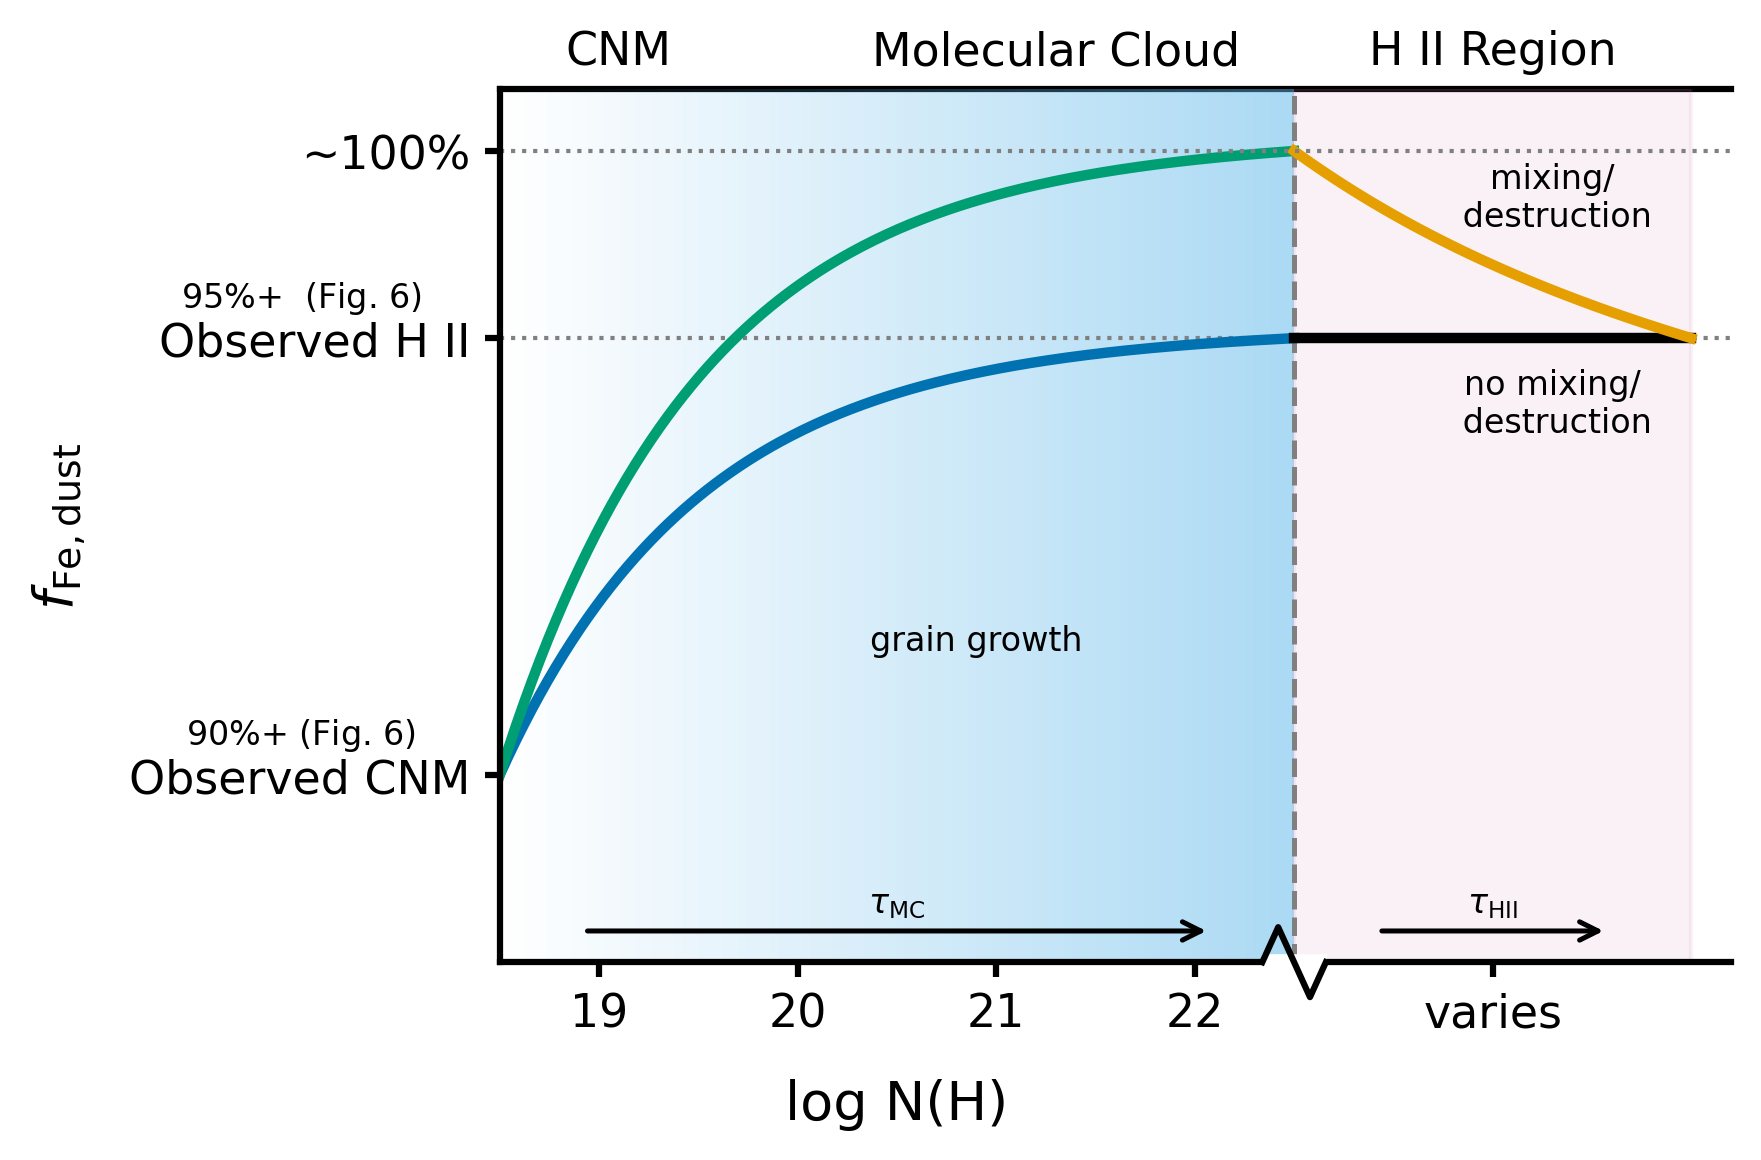

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# font settings

plt.rcParams.update({"text.usetex" : False, "font.family" : "sans-serif", "font.size" : 11, "axes.linewidth" : 1.5, "xtick.major.width" : 1.5, "ytick.major.width" : 1.5})

# initiate the figure, I set dpi = 300 for high quality export

fig, ax = plt.subplots(figsize = (6, 4), dpi = 300)

# pseudo x-axis or t-axis from 0 to 20

t1 = np.linspace(0, 20, 200)

# from x = 0 to x = 20, progressively fill in Okabe-Ito blue with higher alpha

x_start = 0
x_end = 20

num_slices = 100
x_edges = np.linspace(x_start, x_end, num_slices + 1)
alpha = 0

for i in range(num_slices):
    ax.axvspan(x_edges[i], x_edges[i + 1], color = "#56B4E9", alpha = alpha, lw = 0)
    alpha += 0.5 / num_slices

# fill Okabe-Ito red for x = 20 to x = 30

ax.axvspan(20, 30, color = "#CC79A7", alpha = 0.1)

# vertical line marking end of molecular cloud phase

ax.axvline(x = 20, color = "gray", linestyle = "--", linewidth = 1.2)

# drawing minimum grain growth + no mixing trajectory

f_min = 90
f_max = 97
tau_growth = 5

ax.axhline(y = f_max, color = "gray", linestyle = ":", linewidth = 1)

raw_end_value = f_max - (f_max - f_min) * np.exp(-20 / tau_growth)

deficit = f_max - raw_end_value
f1 = t1 / 20 * (f_max - f_min) + f_min # (f_max - (f_max - f_min) * np.exp(-t1 / tau_growth)) + (deficit * (t1 / 20))
f1 = (f_max - (f_max - f_min) * np.exp(-t1 / tau_growth)) + (deficit * (t1 / 20))
t2 = np.linspace(20, 30, 100)
f2 = np.full_like(t2, f1[-1])

ax.plot(t1, f1, color = "#0072B2", linewidth = 2.5)
ax.plot(t2, f2, color = "0", linewidth = 2.5)

# drawing maximum grain growth + maximum mixing trajectory

f_min = 90
f_max = 100
tau_growth = 5

raw_end_value = f_max - (f_max - f_min) * np.exp(-20 / tau_growth)

deficit = f_max - raw_end_value
f1 = t1 / 20 * (f_max - f_min) + f_min # (f_max - (f_max - f_min) * np.exp(-t1 / tau_growth)) + (deficit * (t1 / 20))
f1 = (f_max - (f_max - f_min) * np.exp(-t1 / tau_growth)) + (deficit * (t1 / 20))
t2 = np.linspace(20, 30, 100)

raw_end_value = f_max - (3 - 3 * np.exp(-10 / 8))
deficit = 97 - raw_end_value
f2 = (f_max - (3 - 3 * np.exp(-(t2 - 20) / 8))) + (deficit * ((t2 - 20) / 10))

ax.plot(t1, f1, color = "#009E73", linewidth = 2.5)
ax.plot(t2, f2, color = "#E69F00", linewidth = 2.5)

ax.axhline(y = f_max, color = "gray", linestyle = ":", linewidth = 1)

# Add texts and arrows

ax.text(12, 92, "grain growth", fontsize = 8, ha = "center")
ax.text(26.5, 98.8, "mixing/\n destruction", fontsize = 8, ha = "center")
ax.text(26.5, 95.5, "no mixing/\n destruction", fontsize = 8, ha = "center")

ax.annotate("", xy = (18, 87.5), xytext = (2, 87.5), arrowprops = dict(arrowstyle = "->", color = "black", linewidth = 1.2))
ax.text(10, 87.8, r"$\tau_{\rm MC}$", fontsize = 8, ha = "center")

ax.annotate("", xy = (28, 87.5), xytext = (22, 87.5), arrowprops = dict(arrowstyle = "->", color = "black", linewidth = 1.2))
ax.text(25, 87.8, r"$\tau_{\rm H II}$", fontsize = 8, ha = "center")

ax.text(-5, 90.5, r"$90\%$+ (Fig. 6)", fontsize = 8, ha = "center")
ax.text(-5, 97.5, "$95\%$+  (Fig. 6)", fontsize = 8, ha = "center")

# set first x and y labels

ax.set_xlabel("log N(H)", fontsize = 13, labelpad = 10, x = 10 / 31)
ax.set_ylabel(r"$f_{\rm Fe, dust}$", fontsize = 13, labelpad = 10)

# set axis limits

ax.set_xlim(0, 31)
ax.set_ylim(87, 101)

# map the pseudo x-axis to true NHI values

ax2 = ax.secondary_xaxis('top')
ax.set_xticks([2.5, 7.5, 12.5, 17.5, 25])
ax.set_xticklabels(["19", "20", "21", "22", "varies"])

# add secondary x-axis for evolutionary stage

ax2.set_xticks([3, 14, 25])
ax2.set_xticklabels(["CNM", "Molecular Cloud", "H II Region"])
ax2.tick_params(axis = 'x', length = 0)

# map the pseudo y-axis to true iron depletion

ax.set_yticks([90, 97, 100])
ax.set_yticklabels(["Observed CNM", "Observed H II", "~100%"])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

trans = ax.get_xaxis_transform()

# manually block the x-axis:)

ax.plot([19.4, 20.6], [0, 0], color = "white", linewidth = 4, transform = trans, clip_on = False, zorder = 10)

# manually plot some zigzags...

dx = 0.8   
dy = 0.04  

x_zz = [20 - dx, 20 - dx / 2, 20 + dx / 2, 20 + dx]
y_zz = [0, dy, -dy, 0]

# export...

ax.plot(x_zz, y_zz, color = "black", linewidth = 1.5, transform = trans, clip_on = False, zorder = 11)
plt.tight_layout()
plt.savefig("schematic.png", bbox_inches="tight")
plt.show()